In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from src.simulation import simulate_gbm, simulate_ou
from src.pricing import price_european_call

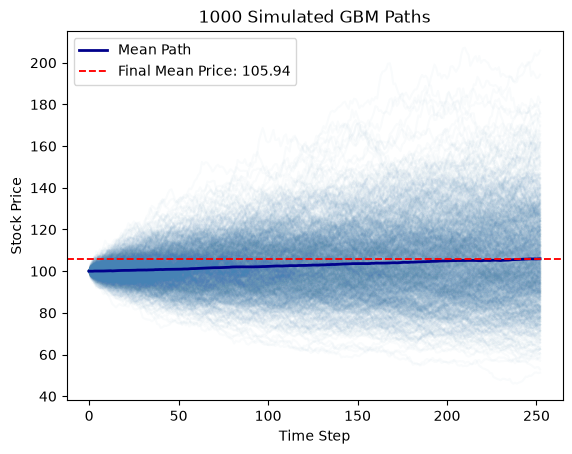

In [2]:
M = 1000
all_paths = []

for i in range(M):
    path = simulate_gbm(S0=100, mu=0.05, sigma=0.2, T=1, N=252)
    all_paths.append(path)
    plt.plot(path, color = "steelblue", alpha=0.03)

all_paths = np.array(all_paths)
mean_path = np.mean(all_paths, axis=0)

plt.plot(mean_path, color = "darkblue", label="Mean Path", linewidth=2)
final_price = mean_path[-1]
plt.axhline(y=final_price, color='red', linewidth=1.35, linestyle='--', label=f"Final Mean Price: {final_price:.2f}")
plt.legend()
plt.xlabel("Time Step")
plt.ylabel("Stock Price")
plt.title(f"{M} Simulated GBM Paths")
plt.show()


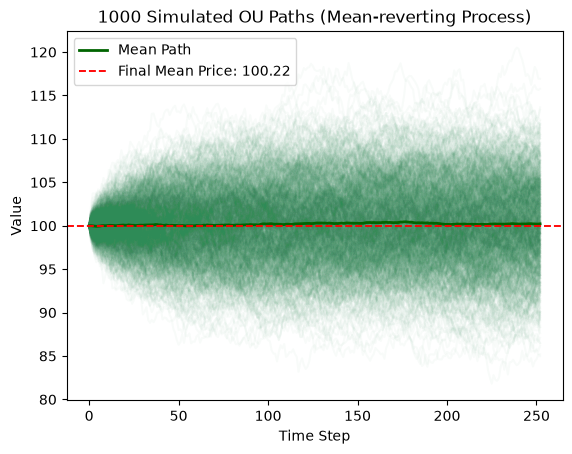

In [3]:
M = 1000
ou_paths = []

for i in range(M):
    path = simulate_ou(X0=100, theta=2, mu=100, sigma=10, T=1, N=252)
    ou_paths.append(path)
    plt.plot(path, color = "seagreen", alpha=0.03)

ou_paths = np.array(ou_paths)
ou_mean = np.mean(ou_paths, axis=0)

plt.plot(ou_mean, color = "darkgreen", label="Mean Path", linewidth=2)
plt.axhline(100, color='red', linewidth=1.35, linestyle='--', label=f"Final Mean Price: {ou_mean[-1]:.2f}")
plt.legend()
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.title(f"{M} Simulated OU Paths (Mean-reverting Process)")
plt.show()

In [4]:

price = price_european_call(S0=100, K=100, r=0.05, sigma=0.2, T=1, N=252, M=10000)
print(price)

10.355049712694328


In [5]:
from src.pricing import black_scholes_call
print(black_scholes_call(S0=100, K=100, r=0.05, sigma=0.2, T=1))

10.450583572185565


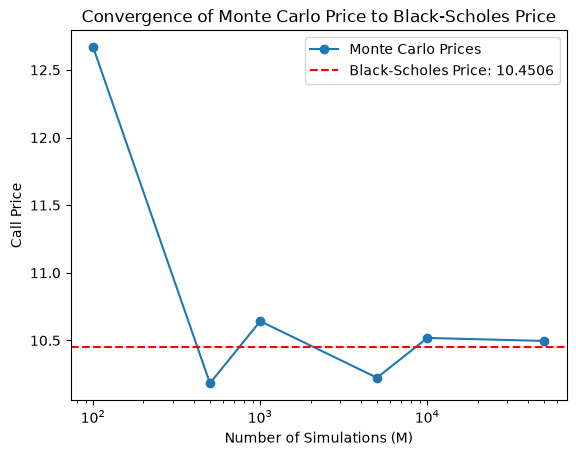

In [6]:
Ms = [100, 500, 1000, 5000, 10000, 50000]
mc_prices = []
for m in Ms:
    p = price_european_call(S0=100, K=100, r=0.05, sigma=0.2, T=1, N=252, M=m)
    mc_prices.append(p)

bs = black_scholes_call(S0=100, K=100, r=0.05, sigma=0.2, T=1)

plt.plot(Ms, mc_prices, marker='o', label='Monte Carlo Prices')
plt.axhline(y=bs, color='red', linestyle='--', label=f'Black-Scholes Price: {bs:.4f}')
plt.xscale('log')
plt.xlabel('Number of Simulations (M)')
plt.ylabel('Call Price')
plt.legend()
plt.title('Convergence of Monte Carlo Price to Black-Scholes Price')
plt.show()

In [7]:
from src.pricing import price_asian_call
asian_price = price_asian_call(S0=100, K=100, r=0.05, sigma=0.2, T=1, N=252, M=10000)
print("Asian call price:", asian_price)

Asian call price: 5.914622281911438


In [8]:
from src.pricing import price_european_call_antithetic
p = price_european_call_antithetic(S0=100, K=100, r=0.05, sigma=0.2, T=1, M=10000)
print("Antithetic price:", p)

Antithetic price: 10.55103605266537


In [9]:
from src.pricing import bs_delta_call, fd_delta_call

print("Analytical Delta (Black-Scholes):", bs_delta_call(S0=100, K=100, r=0.05, sigma=0.2, T=1))
print("Finite Difference Delta:", fd_delta_call(S0=100, K=100, r=0.05, sigma=0.2, T=1))

Analytical Delta (Black-Scholes): 0.6368306511756191
Finite Difference Delta: 0.6368306425763137


In [10]:
from src.pricing import bs_vega_call, bs_gamma_call, bs_theta_call, bs_rho_call
args = dict(S0=100, K=100, r=0.05, sigma=0.2, T=1)
print("Vega: ", bs_vega_call(**args))
print("Gamma:", bs_gamma_call(**args))
print("Theta:", bs_theta_call(**args))
print("Rho:  ", bs_rho_call(**args))

Vega:  37.52403469169379
Gamma: 0.018762017345846895
Theta: -6.414027546438197
Rho:   53.232481545376345


In [11]:
from src.pricing import implied_vol_call
iv = implied_vol_call(market_price=10.4506, S0=100, K=100, r=0.05, T=1)
print("Implied Volatility:", iv)

Implied Volatility: 0.20000043779443288


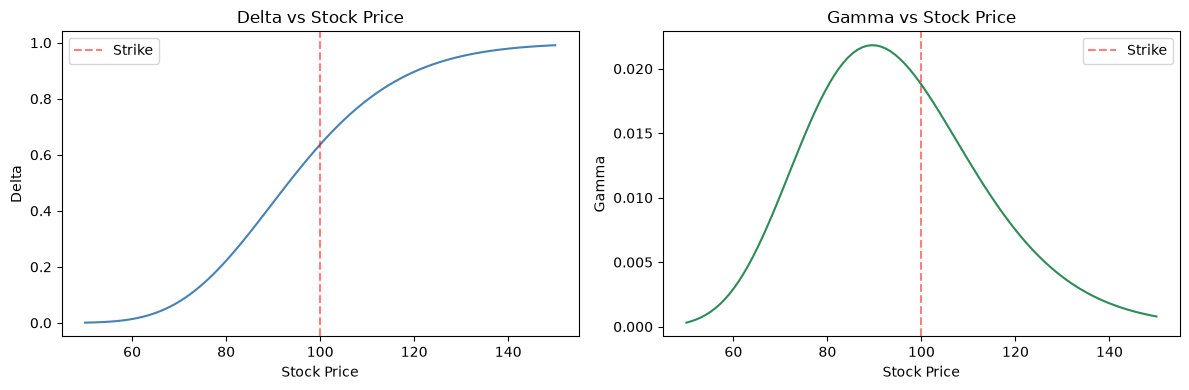

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from src.pricing import bs_delta_call, bs_gamma_call

stock_prices = np.linspace(50, 150, 100)   # 100 prices from 50 to 150

deltas = [bs_delta_call(S0, 100, 0.05, 0.2, 1) for S0 in stock_prices]
gammas = [bs_gamma_call(S0, 100, 0.05, 0.2, 1) for S0 in stock_prices]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(stock_prices, deltas, color="steelblue")
ax1.axvline(100, color="red", linestyle="--", alpha=0.5, label="Strike")
ax1.set_xlabel("Stock Price"); ax1.set_ylabel("Delta"); ax1.set_title("Delta vs Stock Price"); ax1.legend()

ax2.plot(stock_prices, gammas, color="seagreen")
ax2.axvline(100, color="red", linestyle="--", alpha=0.5, label="Strike")
ax2.set_xlabel("Stock Price"); ax2.set_ylabel("Gamma"); ax2.set_title("Gamma vs Stock Price"); ax2.legend()

plt.tight_layout()
plt.show()

In [13]:
from src.simulation import simulate_gbm
from src.estimation import estimate_gbm

path = simulate_gbm(S0=100, mu=0.08, sigma=0.25, T=1.0, N=252)
mu_hat, sigma_hat = estimate_gbm(path, dt=1/252)
print("True: mu=0.08, sigma=0.25")
print(f"Estimated: mu={mu_hat:.4f}, sigma={sigma_hat:.4f}")

True: mu=0.08, sigma=0.25
Estimated: mu=0.2834, sigma=0.2811


In [15]:
from src.simulation import simulate_ou
from src.estimation import estimate_ou

# simulate with KNOWN parameters
ou_path = simulate_ou(X0=100, theta=2.0, mu=100, sigma=10, T=1.0, N=252)

theta_hat, mu_hat, sigma_hat = estimate_ou(ou_path, dt=1/252)
print("True: theta=2.0, mu=100, sigma=10")
print(f"Estimated: theta={theta_hat:.3f}, mu={mu_hat:.3f}, sigma={sigma_hat:.3f}")

True: theta=2.0, mu=100, sigma=10
Estimated: theta=11.161, mu=96.052, sigma=10.558


In [19]:
import yfinance as yf
import numpy as np
from src.estimation import estimate_gbm

# Download ~5 years of daily S&P 500 prices
data = yf.download("TSLA", start="2019-01-01", end="2024-01-01")
prices = data["Close"].dropna().values.flatten()

print("Number of price points:", len(prices))

# Fit GBM (dt = 1 trading day = 1/252 of a year)
mu_hat, sigma_hat = estimate_gbm(prices, dt=1/252)
print(f"Estimated annual drift (mu):       {mu_hat:.4f}")
print(f"Estimated annual volatility (sigma): {sigma_hat:.4f}")

[*********************100%***********************]  1 of 1 completed

Number of price points: 1258
Estimated annual drift (mu):       0.7078
Estimated annual volatility (sigma): 0.6470


In [20]:
import yfinance as yf
import numpy as np
from src.estimation import estimate_ou

# Two cointegrated stocks — Coca-Cola and Pepsi
data = yf.download(["KO", "PEP"], start="2019-01-01", end="2024-01-01")["Close"].dropna()

ko  = data["KO"].values
pep = data["PEP"].values

# The spread: how far KO deviates from a fitted multiple of PEP
# (simple version: ratio-based spread)
hedge_ratio = np.polyfit(pep, ko, 1)[0]     # how many KO per PEP
spread = ko - hedge_ratio * pep

# Fit OU to the spread
theta, mu, sigma = estimate_ou(spread, dt=1/252)
print(f"Reversion speed (theta): {theta:.3f}")
print(f"Long-run mean (mu):      {mu:.3f}")
print(f"Volatility (sigma):      {sigma:.3f}")

# Half-life of reversion: how long to close half the gap
half_life = np.log(2) / theta
print(f"Half-life of reversion:  {half_life:.3f} years  (~{half_life*252:.0f} trading days)")

[*********************100%***********************]  2 of 2 completed

Reversion speed (theta): 4.101
Long-run mean (mu):      11.838
Volatility (sigma):      6.140
Half-life of reversion:  0.169 years  (~43 trading days)
